Visualization #1: US Gun Killings in 2018

https://guns.periscopic.com/

- animation (not neutral, dramatic, emotional) 
- biased or critial <== race is included

highlighting the lack of gun control

Visualization #2: Washington Post Active Shooters

-- Number of active shooters per year (from 2000 to 2015)
- neutral emotional field
- no fancy animation <- avoid conveying an emotional narrative to the audience


Publish alongside with the unemployment rate graph:
- actually talking about the same thing, just from different perspective (Republicans vs Democrats)

Activity - Python Graph Gallery : Adding jitter to a boxplot distribution

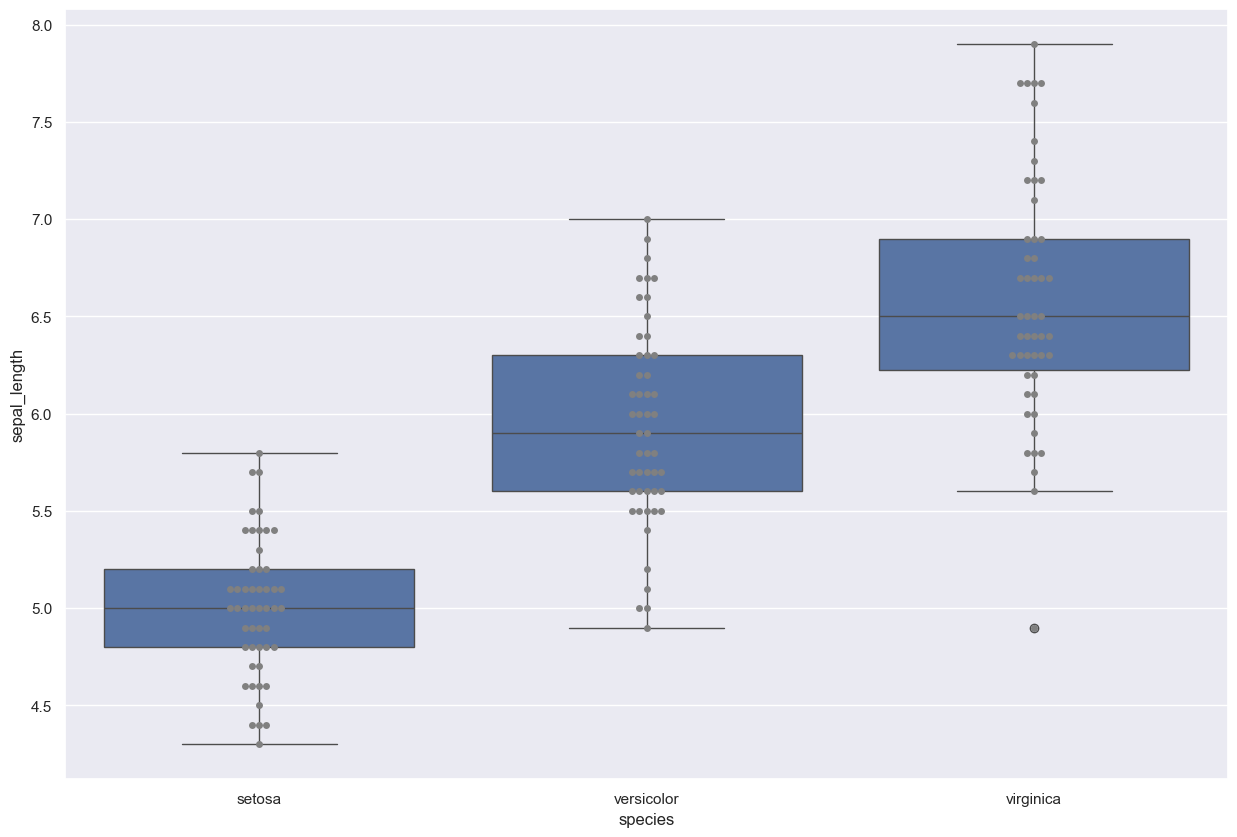

In [10]:
# libraries & dataset
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="darkgrid")
df = sns.load_dataset('iris')

# Usual boxplot
ax = sns.boxplot(x='species', y='sepal_length', data=df)
 
# Add jitter with the swarmplot function
ax = sns.swarmplot(x='species', y='sepal_length', data=df, color="grey")
plt.show()

Activity - Python Graph Gallery:
Basic 3d density chart

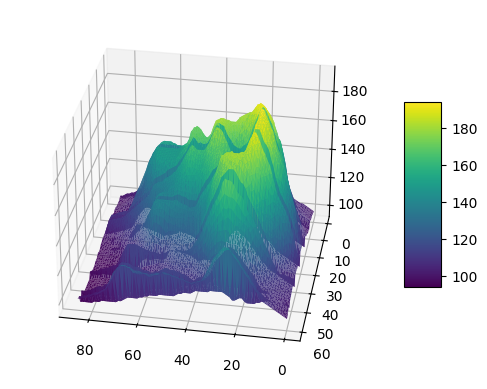

In [1]:
# Import necessary libraries
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Get the data (csv file is hosted on the web)
url = 'https://raw.githubusercontent.com/holtzy/The-Python-Graph-Gallery/master/static/data/volcano.csv'
data = pd.read_csv(url)

# Transform it to a long format
df = data.unstack().reset_index()
df.columns = ["X", "Y", "Z"]

# Transform the old column name in something numeric
df['X'] = pd.Categorical(df['X'])
df['X'] = df['X'].cat.codes

# Create the plot
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Plot the data
trisurf = ax.plot_trisurf(df['Y'], df['X'], df['Z'], cmap=plt.cm.viridis, linewidth=0.2)

# Set the angle of the camera
ax.view_init(30, 100)

# Add color bar which maps values to colors
fig.colorbar(trisurf, ax=ax, shrink=0.5, aspect=5)

# Show the plot
plt.show()

3D - Rotate the Camera

MovieWriter ffmpeg unavailable; using Pillow instead.


KeyboardInterrupt: 

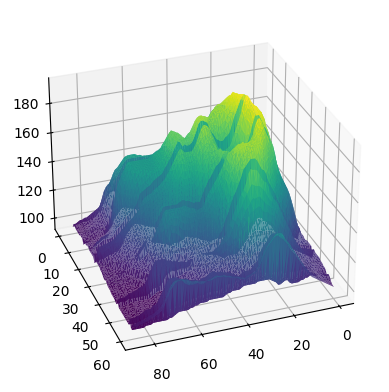

In [3]:
# Import necessary libraries
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import pandas as pd
import seaborn as sns

# Get the data (csv file is hosted on the web)
url = 'https://raw.githubusercontent.com/holtzy/The-Python-Graph-Gallery/master/static/data/volcano.csv'
data = pd.read_csv(url)

# Transform it to a long format
df = data.unstack().reset_index()
df.columns = ["X", "Y", "Z"]

# Transform the old column name in something numeric
df['X'] = pd.Categorical(df['X'])
df['X'] = df['X'].cat.codes

# Create the plot
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

def update(frame):
    ax.clear()
    trisurf = ax.plot_trisurf(df['Y'], df['X'], df['Z'], cmap=plt.cm.viridis, linewidth=0.2)
    ax.view_init(30, 70+frame)
    return fig,

import os

ani = FuncAnimation(fig, update, frames=range(0, 180))

# Create the directory if it doesn't exist
output_dir = '../../static/animations'
os.makedirs(output_dir, exist_ok=True)

ani.save(os.path.join(output_dir, 'volcano.gif'), fps=30)

Activity - Python Graph Gallery : Bubble map with Python and Basemap

In [4]:
# Libraries
import pandas as pd

# read the data (on the web)
data = pd.read_csv('https://raw.githubusercontent.com/holtzy/The-Python-Graph-Gallery/master/static/data/TweetSurfData.csv', sep=";")

# Check the first 2 rows
data.head(2)

,homelon,homelat,homecontinent,n
0,-178.12,-14.29,Australia,10
1,-172.10,-13.76,NaN,2


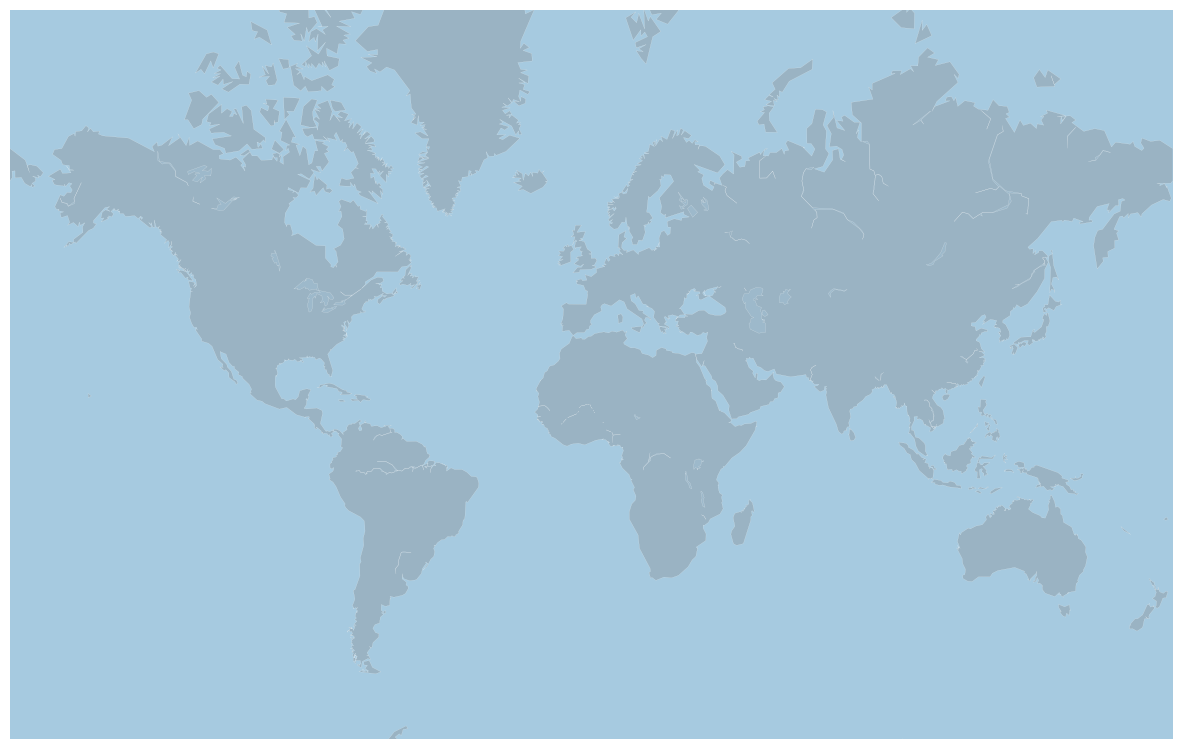

In [8]:
# Basemap library
#%pip install basemap-data basemap
from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt
 
# Set the dimension of the figure
plt.rcParams["figure.figsize"]=15,10;

# Make the background map
m=Basemap(llcrnrlon=-180, llcrnrlat=-65, urcrnrlon=180, urcrnrlat=80, projection='merc');
m.drawmapboundary(fill_color='#A6CAE0', linewidth=0);
m.fillcontinents(color='grey', alpha=0.3);
m.drawcoastlines(linewidth=0.1, color="white");


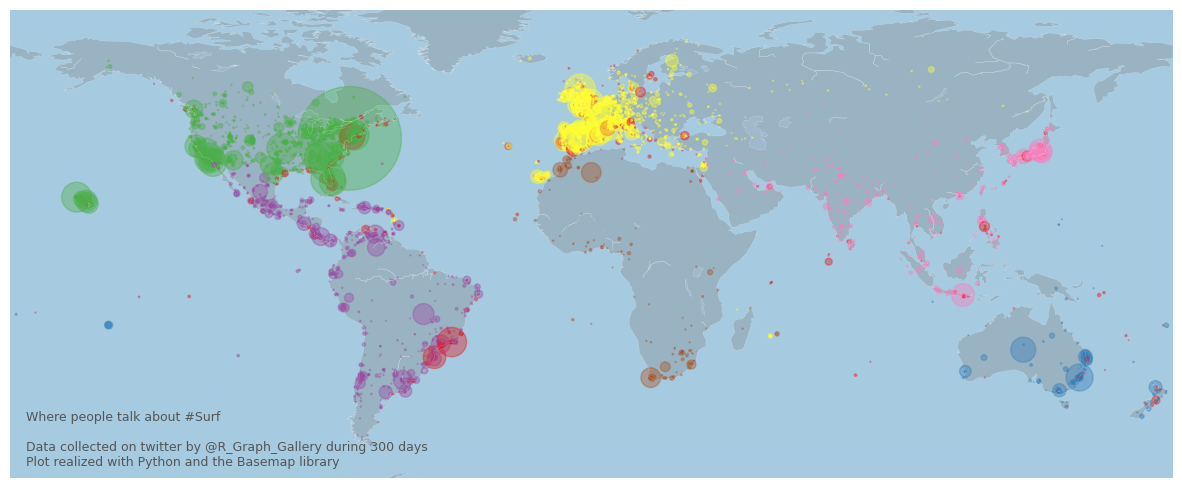

In [9]:
# Make the background map
m=Basemap(llcrnrlon=-180, llcrnrlat=-65, urcrnrlon=180, urcrnrlat=80)
m.drawmapboundary(fill_color='#A6CAE0', linewidth=0)
m.fillcontinents(color='grey', alpha=0.3)
m.drawcoastlines(linewidth=0.1, color="white")

# prepare a color for each point depending on the continent.
data['labels_enc'] = pd.factorize(data['homecontinent'])[0]
 
# Add a point per position
m.scatter(
    x=data['homelon'], 
    y=data['homelat'], 
    s=data['n']/6, 
    alpha=0.4, 
    c=data['labels_enc'], 
    cmap="Set1"
)
 
# copyright and source data info
plt.text( -175, -62,'Where people talk about #Surf\n\nData collected on twitter by @R_Graph_Gallery during 300 days\nPlot realized with Python and the Basemap library', ha='left', va='bottom', size=9, color='#555555' );